In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

In [27]:
n_paths = 10**4
n_steps = 10**4
eps_clip = 1e-12
T = 100
mu = 0.01
epsilon = 0.01
sqrt_epsilon = np.sqrt(epsilon)

def f(r):
    return np.pi-r

def wall_rep(r):
    return 1/r+1/(r-2*np.pi)

dt = T / n_steps

def F(y, rhs):
    
    return y - rhs - 2 * mu * dt * (
        np.pi - y + 1/y + 1/(y - 2*np.pi)
    )

def dF(y, rhs):
    
    return 1 + 2 * mu * dt * (
        1 + 1/y**2 + 1/(y - 2*np.pi)**2
    )

def d2F(y, rhs):
    return -4 * mu * dt * (
        1/y**3 + 1/(y - 2*np.pi)**3
    )


In [28]:
def backward_euler_step(C, k, newton_iters=2):
    """
    Vectorized NumPy backward Euler solve for

        x = C + k * (pi - x + 1/x + 1/(x - 2*pi))

    i.e. solves

        F(x; C) = x - C - k * (pi - x + 1/x + 1/(x - 2*pi)) = 0

    and returns the root in (0, 2*pi). If no admissible root is found,
    returns NaN for that entry.
    """
    C = np.asarray(C, dtype=np.float64)
    a = 2.0 * np.pi
    b = np.pi
    kk = float(k)

    def rcbrt(z):
        """Real cube root, valid also for negative z."""
        return np.sign(z) * np.abs(z) ** (1.0 / 3.0)

    def Fval(x, C):
        """Residual of the correct implicit equation."""
        return x - C - kk * (b - x + 1.0 / x + 1.0 / (x - a))

    def dFval(x):
        """Derivative with respect to x."""
        return 1.0 + kk * (1.0 + 1.0 / x**2 + 1.0 / (x - a)**2)

    # Degenerate case k = 0: then x = C
    if abs(kk) < 1e-100:
        x = C.copy()
        x[(x <= 0.0) | (x >= a)] = np.nan
        return x

    # ------------------------------------------------------------
    # Derive cubic:
    #
    #   A x^3 + B x^2 + G x + D = 0
    #
    # from
    #
    #   x - C - k*(pi - x + 1/x + 1/(x-2*pi)) = 0
    #
    # The coefficients are:
    #
    #   A = 1 + k
    #   B = -(C + a + k(a + pi))
    #   G = aC + ak*pi - 2k
    #   D = ak
    # ------------------------------------------------------------
    A = 1.0 + kk
    B = -(C + a + kk * (a + b))
    G = a * C + a * b * kk - 2.0 * kk
    D = a * kk

    # Depressed cubic y^3 + p y + q = 0, with x = y - B/(3A)
    p = (3.0 * A * G - B * B) / (3.0 * A * A)
    q = (2.0 * B * B * B - 9.0 * A * B * G + 27.0 * A * A * D) / (27.0 * A * A * A)
    Delta = 0.25 * q * q + (p * p * p) / 27.0
    shift = -B / (3.0 * A)

    x = np.full_like(C, np.nan, dtype=np.float64)

    # Case 1: one real root
    mask1 = Delta >= 0.0
    if np.any(mask1):
        sqrtD = np.sqrt(Delta[mask1])
        s1 = rcbrt(-0.5 * q[mask1] + sqrtD)
        s2 = rcbrt(-0.5 * q[mask1] - sqrtD)
        x1 = s1 + s2 + shift[mask1]

        valid1 = (x1 > 0.0) & (x1 < a)
        tmp = np.full_like(x1, np.nan)
        tmp[valid1] = x1[valid1]
        x[mask1] = tmp

    # Case 2: three real roots
    mask3 = ~mask1
    if np.any(mask3):
        p3 = p[mask3]
        q3 = q[mask3]
        shift3 = shift[mask3]
        C3 = C[mask3]

        rho = 2.0 * np.sqrt(-p3 / 3.0)
        arg = (-0.5 * q3) / np.sqrt(-((p3 / 3.0) ** 3))
        arg = np.clip(arg, -1.0, 1.0)
        phi = np.arccos(arg)

        r0 = rho * np.cos(phi / 3.0) + shift3
        r1 = rho * np.cos((phi + 2.0 * np.pi) / 3.0) + shift3
        r2 = rho * np.cos((phi + 4.0 * np.pi) / 3.0) + shift3

        roots = np.vstack([r0, r1, r2])
        valid = (roots > 0.0) & (roots < a)

        residuals = np.abs(Fval(roots, C3[None, :]))
        residuals[~valid] = np.inf

        best_idx = np.argmin(residuals, axis=0)
        best_res = residuals[best_idx, np.arange(residuals.shape[1])]
        best_root = roots[best_idx, np.arange(roots.shape[1])]

        chosen = np.full_like(best_root, np.nan)
        ok = np.isfinite(best_res)
        chosen[ok] = best_root[ok]

        x[mask3] = chosen


    return x

In [29]:

X_s = np.zeros((n_paths, n_steps + 1))
X_s[:, 0] = np.pi
W_s = np.sqrt(dt) * np.random.normal(size=(n_paths, n_steps))
k= 2*dt*mu

for i in range(n_steps):
    C = X_s[:, i] + 2 * sqrt_epsilon * W_s[:, i]


    # initial guess
    #y0 = X_s[:, i]

    # Halley's method
    #X_s[:, i+1] = newton(
    #    F,
    #    y0,
    #    fprime=dF,
    #    fprime2=d2F,
    #    args=(rhs,),
    #    tol=1e-12,
    #    maxiter=1000
    #)

    X_s[:, i+1] = backward_euler_step(C, k)

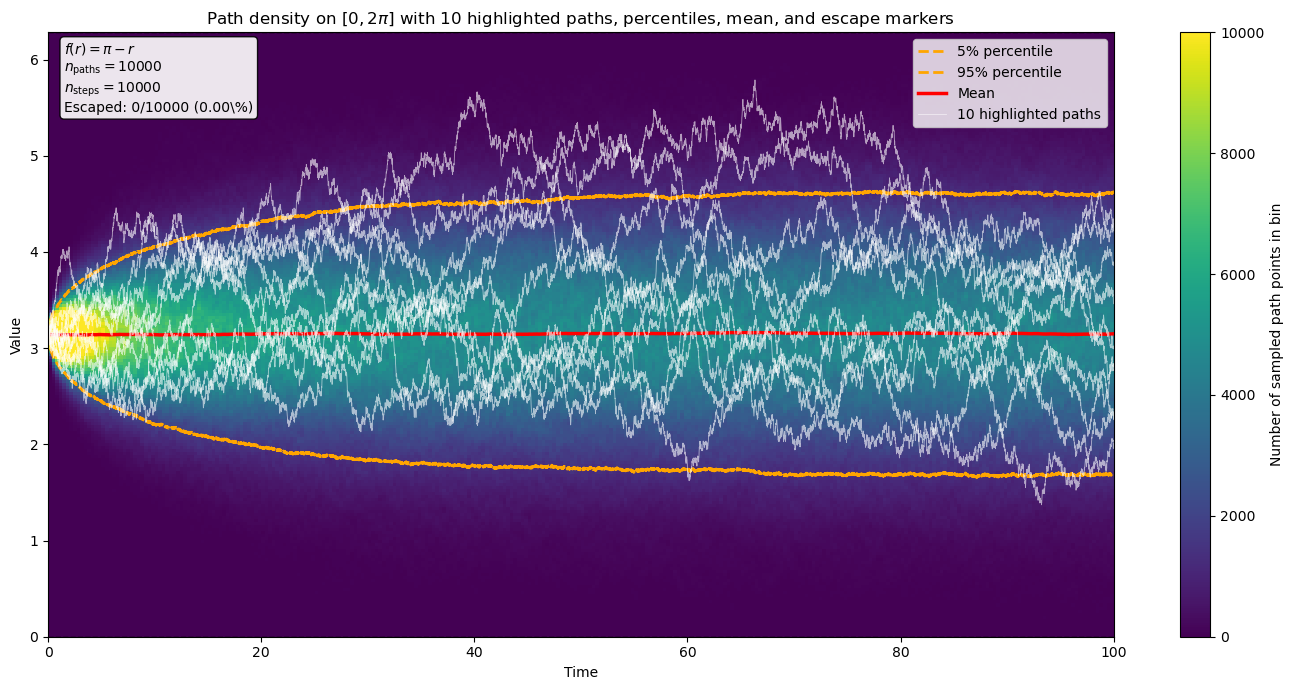

Escaped paths: 0 / 10000
Fraction escaped: 0.000000


In [30]:
# ============================================================
# PLOTTING ONLY
# Density plot in (time, value) on [0, 2pi], with 10 paths
# highlighted, 5%/95% percentile lines, mean line,
# and escape markers
# ============================================================

y_min, y_max = 0.0, 2 * np.pi

# ---------------------------------
# 1. Subsample in time for plotting
# ---------------------------------
n_time_plot = n_steps
time_idx = np.linspace(0, n_steps, n_time_plot, dtype=int)
t_plot = time_idx * dt
X_plot = X_s[:, time_idx]   # shape: (n_paths, n_time_plot)

# ---------------------------------
# 2. Detect escapes
# ---------------------------------
escaped_mask = np.any((X_s < y_min) | (X_s > y_max) | np.isnan(X_s), axis=1)
escaped_ids = np.where(escaped_mask)[0]

first_escape_idx = np.full(n_paths, -1, dtype=int)
if escaped_ids.size > 0:
    first_escape_idx[escaped_ids] = np.argmax(
        (X_s[escaped_ids] < y_min) | (X_s[escaped_ids] > y_max), axis=1
    )
first_escape_time = np.where(first_escape_idx >= 0, first_escape_idx * dt, np.nan)

# ---------------------------------
# 3. Build density only for values inside [0, 2pi]
# ---------------------------------
in_box = (X_plot >= y_min) & (X_plot <= y_max)

# Flatten only the in-interval values
t_dense = np.broadcast_to(t_plot, X_plot.shape)[in_box]
x_dense = X_plot[in_box]

# ---------------------------------
# 4. Compute statistics inside [0, 2pi]
# ---------------------------------
X_stats = np.where(in_box, X_plot, np.nan)

mean_line = np.nanmean(X_stats, axis=0)
q05_line = np.nanpercentile(X_stats, 5, axis=0)
q95_line = np.nanpercentile(X_stats, 95, axis=0)

# ---------------------------------
# 5. Choose 10 random paths to highlight
# ---------------------------------
rng = np.random.default_rng(12345)
n_highlight = 10
highlight_ids = rng.choice(n_paths, size=min(n_highlight, n_paths), replace=False)

# ---------------------------------
# 6. Escape summary
# ---------------------------------
n_escaped = escaped_mask.sum()
escaped_pct = 100 * n_escaped / n_paths

# ---------------------------------
# 7. Plot
# ---------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Density background
hb = ax.hist2d(
    t_dense,
    x_dense,
    bins=[300, 200],
    range=[[0, T], [y_min, y_max]],
    cmap="viridis",
    vmax=10000   # example cap
)
cbar = plt.colorbar(hb[3], ax=ax)
cbar.set_label("Number of sampled path points in bin")

# Boundary lines
ax.axhline(y_min, linestyle="--", linewidth=1, color="black")
ax.axhline(y_max, linestyle="--", linewidth=1, color="black")

# 5% and 95% percentile lines
ax.plot(t_plot, q05_line, linewidth=2.0, linestyle="--", color="orange", label="5% percentile")
ax.plot(t_plot, q95_line, linewidth=2.0, linestyle="--", color="orange", label="95% percentile")

# Mean line
ax.plot(t_plot, mean_line, linewidth=2.5, color="red", label="Mean")

# Highlight 10 random paths
for j, pid in enumerate(highlight_ids):
    path = X_plot[pid].copy()

    # Plot only the part inside [0, 2pi]
    path_in = np.where((path >= y_min) & (path <= y_max), path, np.nan)
    if j == 0:
        ax.plot(t_plot, path_in, linewidth=0.6, alpha=0.6, color="white", label="10 highlighted paths")
    else:
        ax.plot(t_plot, path_in, linewidth=0.6, alpha=0.6, color="white")

    # If this highlighted path escapes, mark first escape clearly
    fe_idx = first_escape_idx[pid]
    if fe_idx >= 0:
        fe_t = fe_idx * dt
        fe_val = X_s[pid, fe_idx]

        # Mark at the closest boundary for visibility
        marker_y = y_min if fe_val < y_min else y_max
        ax.scatter(
            [fe_t], [marker_y],
            marker="x", s=80, linewidths=2.0, color="red", zorder=5
        )
        ax.axvline(fe_t, color="red", alpha=0.12, linewidth=1)

# Mark first escape times for all escaped paths as a red rug on the boundary
if escaped_ids.size > 0:
    escape_boundary_y = np.where(
        X_s[escaped_ids, first_escape_idx[escaped_ids]] < y_min,
        y_min,
        y_max
    )
    ax.scatter(
        first_escape_time[escaped_ids],
        escape_boundary_y,
        s=6, color="red", alpha=0.25,
        label="First escape times"
    )

# Annotation box
info_text = (
    rf"$f(r)=\pi-r$" "\n"
    rf"$n_{{\mathrm{{paths}}}}={n_paths}$" "\n"
    rf"$n_{{\mathrm{{steps}}}}={n_steps}$" "\n"
    rf"Escaped: {n_escaped}/{n_paths} ({escaped_pct:.2f}\%)"
)
ax.text(
    0.015, 0.985, info_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

ax.set_xlim(0, T)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title(r"Path density on $[0,2\pi]$ with 10 highlighted paths, percentiles, mean, and escape markers")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ---------------------------------
# 8. Optional: print escape summary
# ---------------------------------
print(f"Escaped paths: {n_escaped} / {n_paths}")
print(f"Fraction escaped: {n_escaped / n_paths:.6f}")